In [3]:
# Importing libraries

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sn
from sklearn.model_selection import GridSearchCV,train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler

In [1]:
# Loading the Dataset

In [8]:
zoo = pd.read_csv('Zoo.csv')
zoo

,animal name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,wallaby,1,0,0,1,0,0,0,1,1,1,0,0,2,1,0,1,1
97,wasp,1,0,1,0,1,0,0,0,0,1,1,0,6,0,0,0,6
98,wolf,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1
99,worm,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,7


In [10]:
zoo.shape

(101, 18)

In [12]:
zoo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   animal name  101 non-null    object
 1   hair         101 non-null    int64 
 2   feathers     101 non-null    int64 
 3   eggs         101 non-null    int64 
 4   milk         101 non-null    int64 
 5   airborne     101 non-null    int64 
 6   aquatic      101 non-null    int64 
 7   predator     101 non-null    int64 
 8   toothed      101 non-null    int64 
 9   backbone     101 non-null    int64 
 10  breathes     101 non-null    int64 
 11  venomous     101 non-null    int64 
 12  fins         101 non-null    int64 
 13  legs         101 non-null    int64 
 14  tail         101 non-null    int64 
 15  domestic     101 non-null    int64 
 16  catsize      101 non-null    int64 
 17  type         101 non-null    int64 
dtypes: int64(17), object(1)
memory usage: 14.3+ KB


In [10]:
# We can observe that only "animal name" is object data type.
# We can also observe that there are no null values in the dataset.
# The purpose for this assignment is to be able to predict the animal type, based upon the variables.

In [14]:
zoo[zoo.duplicated()]

,animal name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type


In [ ]:
# There are no duplicate values in the dataset.

In [16]:
# Summary Statistics

zoo.describe()

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
count,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000
mean,0.425743,0.198020,0.584158,0.405941,0.237624,0.356436,0.554455,0.603960,0.821782,0.792079,0.079208,0.168317,2.841584,0.742574,0.128713,0.435644,2.831683
std,0.496921,0.400495,0.495325,0.493522,0.427750,0.481335,0.499505,0.491512,0.384605,0.407844,0.271410,0.376013,2.033385,0.439397,0.336552,0.498314,2.102709
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,1.000000
50%,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000,0.000000,2.000000
75%,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000,1.000000,4.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,8.000000,1.000000,1.000000,1.000000,7.000000


In [18]:
# Target variable

zoo['type'].value_counts()

type
1    41
2    20
4    13
7    10
6     8
3     5
5     4
Name: count, dtype: int64

In [ ]:
# The above table shows the number of animals for each type.

In [20]:
# Dropping the 'animal name' column as it is not required to predict the type of animal.

zoo = zoo.drop('animal name', axis=1)

In [ ]:
# Data Visualization

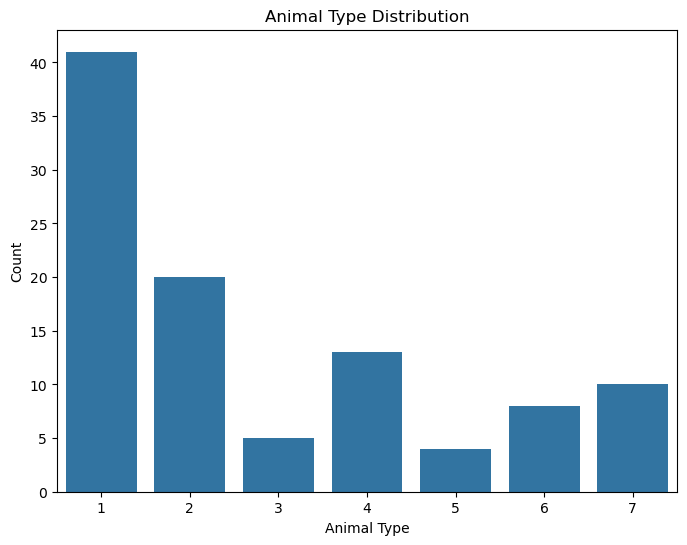

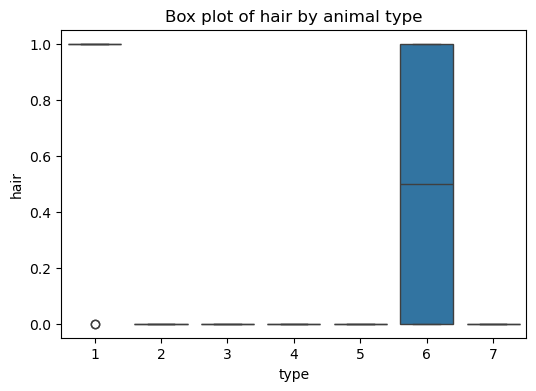

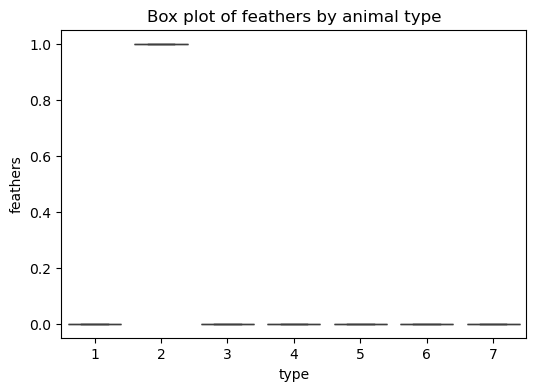

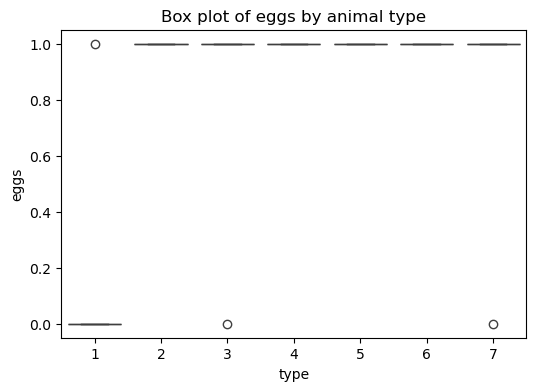

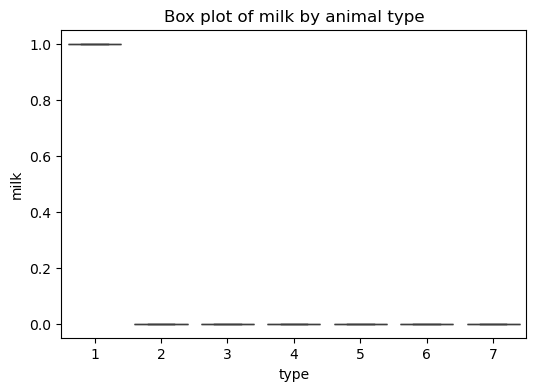

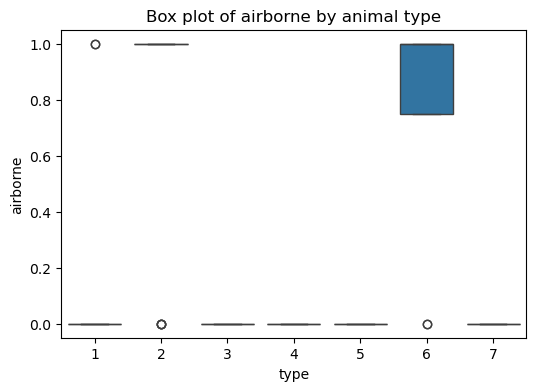

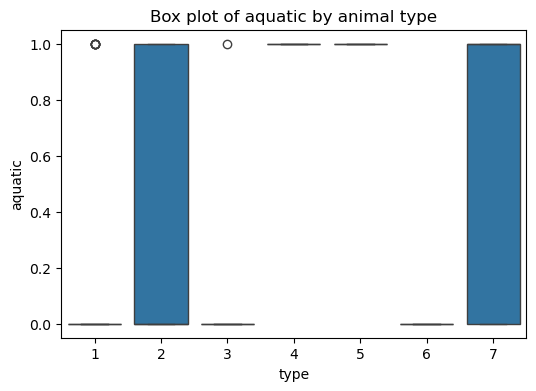

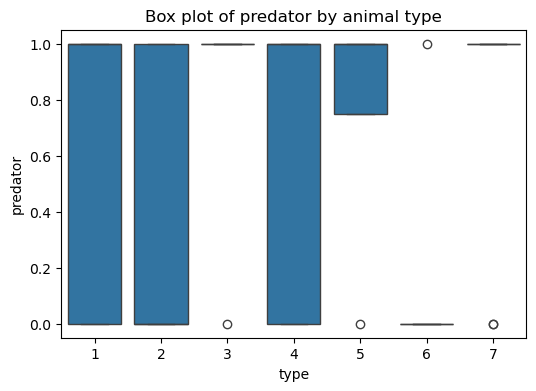

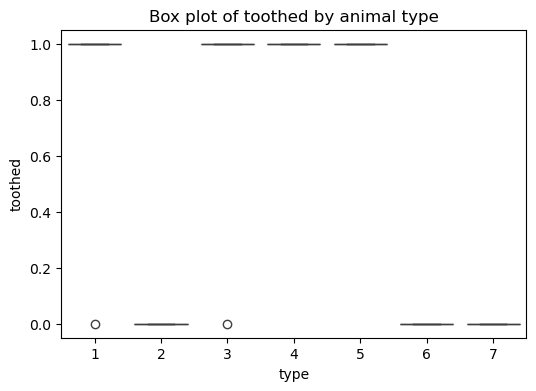

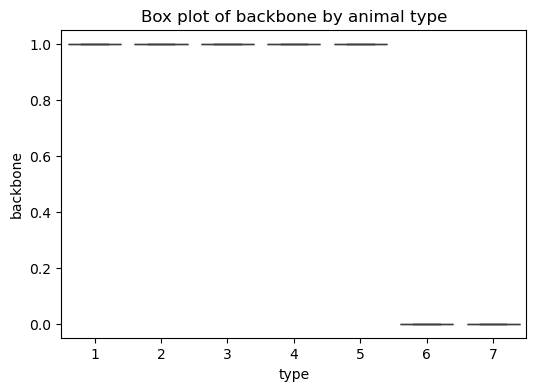

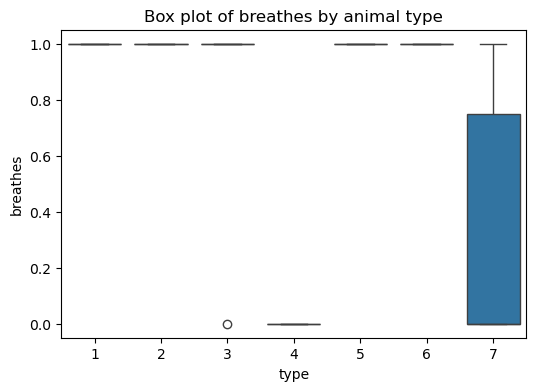

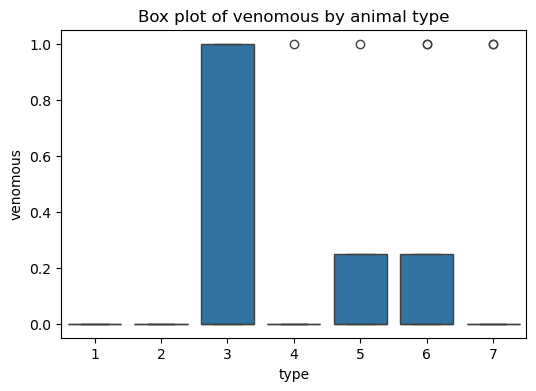

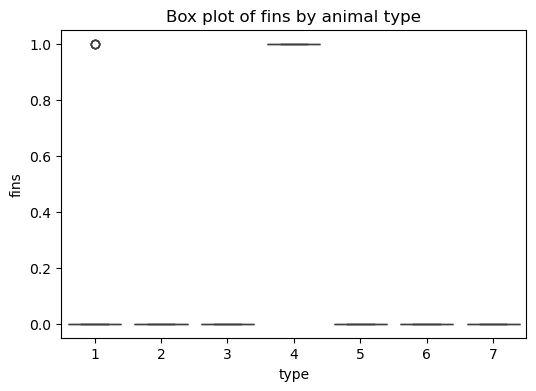

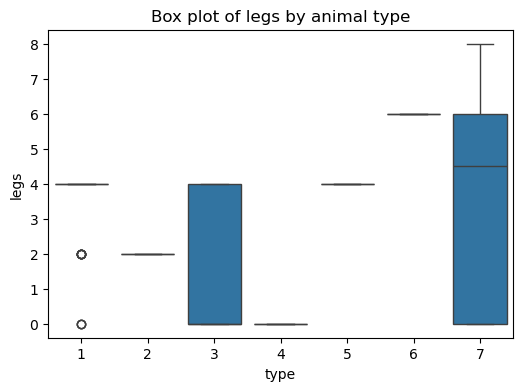

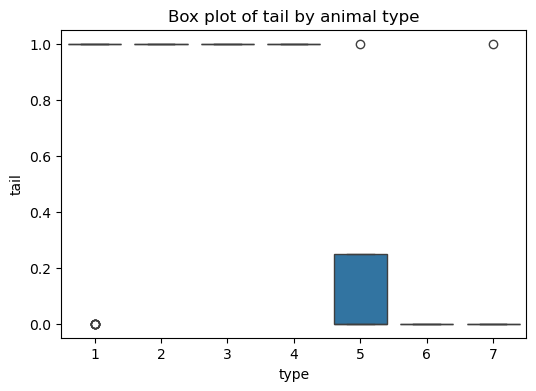

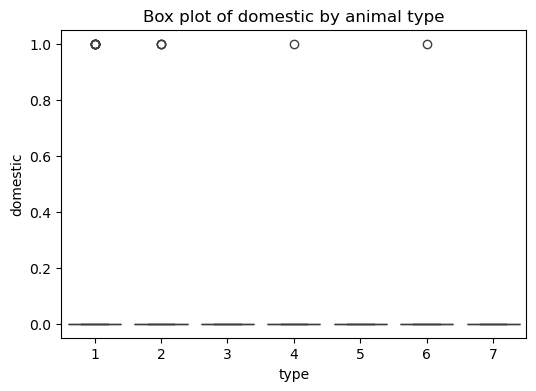

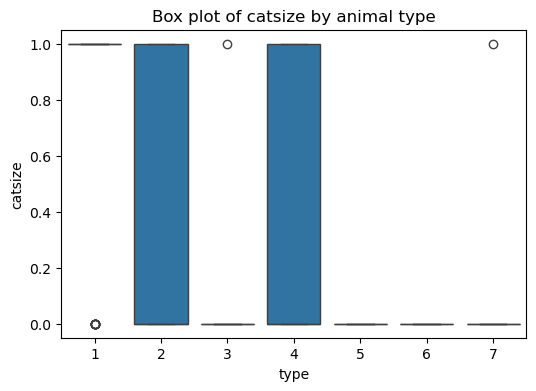

In [22]:
plt.figure(figsize=(8,6))
sn.countplot(x='type', data=zoo)
plt.title('Animal Type Distribution')
plt.xlabel('Animal Type')
plt.ylabel('Count')
plt.show()

# Box plots for numerical features
numerical_features = ['hair', 'feathers', 'eggs', 'milk', 'airborne', 'aquatic', 'predator', 'toothed', 'backbone', 'breathes', 'venomous', 'fins', 'legs', 'tail', 'domestic', 'catsize']
for feature in numerical_features:
    plt.figure(figsize=(6, 4))
    sn.boxplot(x='type', y=feature, data=zoo)
    plt.title(f'Box plot of {feature} by animal type')
    plt.show()

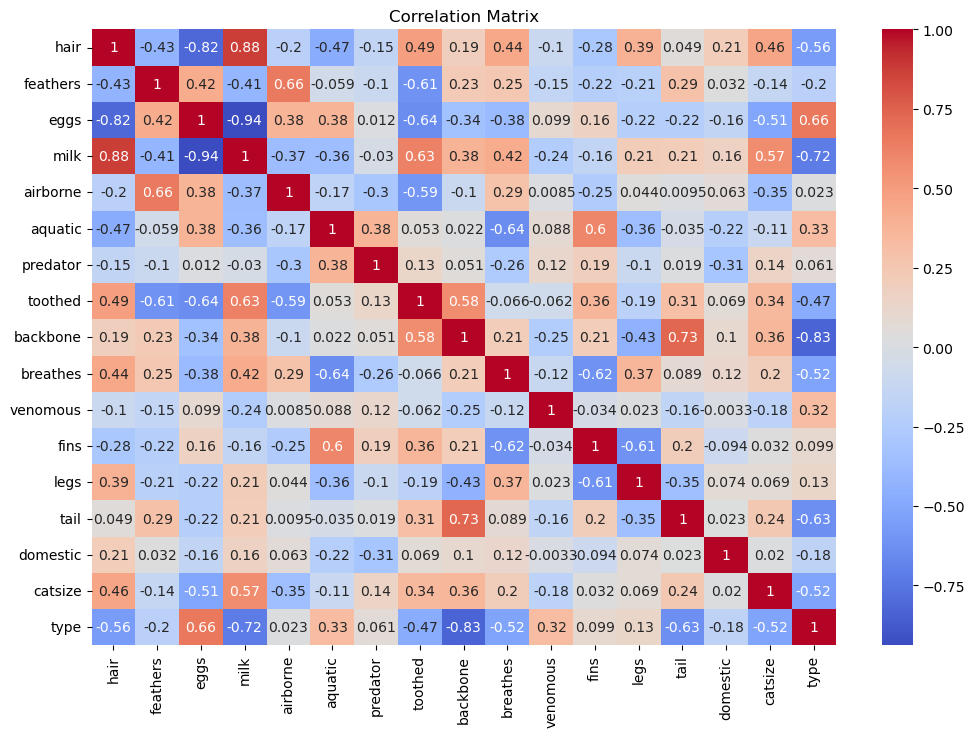

In [24]:
# Correlation Matrix

plt.figure(figsize=(12, 8))
sn.heatmap(zoo.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [ ]:
# The above correlation matrix shows the relation between the variables.

In [ ]:
# Separating the Feature data and Label data(X & Y variables)

In [26]:
X = zoo.drop('type',axis=1)
X.head()

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize
0,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1
1,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1
2,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0
3,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1
4,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1


In [28]:
Y = zoo['type']
Y.head()

0    1
1    1
2    4
3    1
4    1
Name: type, dtype: int64

In [30]:
# Splitting the dataset into Training data and Test data.
# Training data will be 80% and Test data will be 20%.

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = .2, random_state = 30, stratify = Y)
# Checking the X training data
X_train.head()

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize
20,0,1,1,0,1,0,0,0,1,1,0,0,2,1,1,0
64,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1
90,0,0,1,0,0,0,0,0,1,1,0,0,4,1,0,1
59,0,1,1,0,1,0,0,0,1,1,0,0,2,1,0,0
30,0,0,1,0,1,0,0,0,0,1,0,0,6,0,0,0


In [32]:
# Checking the X test data
X_test.head()

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize
46,0,0,1,0,0,1,1,0,0,0,0,0,6,0,0,0
79,0,1,1,0,1,1,1,0,1,1,0,0,2,1,0,0
23,0,1,1,0,1,0,0,0,1,1,0,0,2,1,0,1
60,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,1
97,1,0,1,0,1,0,0,0,0,1,1,0,6,0,0,0


In [34]:
# Checking the Y training data
Y_train.head()

20    2
64    1
90    3
59    2
30    6
Name: type, dtype: int64

In [36]:
# Checking the Y test data
Y_test.head()

46    7
79    2
23    2
60    4
97    6
Name: type, dtype: int64

In [38]:
# Grid search for Algorithm Tuning

n_neighbors = np.array(range(1,40))
param_grid = dict(n_neighbors=n_neighbors)
param_grid

{'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
        35, 36, 37, 38, 39])}

In [40]:
# Finding the best K value
# by applying GridSearch for finding the optimal parameter values.

model = KNeighborsClassifier()
grid = GridSearchCV(estimator=model, param_grid=param_grid,cv=10)
grid.fit(X_train, Y_train)
print(grid.best_params_)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=10.
  warnings.warn(


{'n_neighbors': 1}


In [ ]:
# After applying GridSearch, we got the best K (n_neighbors) value as 1, so we will be using the k= 1 for KNN Classifier algorithm.

/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=10.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=10.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=10.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=10.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=10.
  warnings.warn(
/opt/anaconda3/lib/p

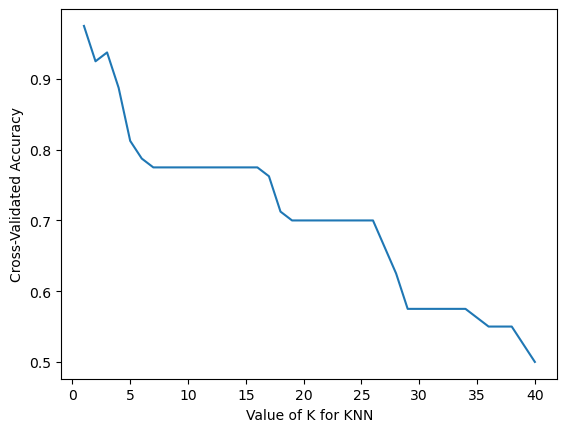

In [42]:
# Visualizing Cross Validation results.

import matplotlib.pyplot as plt
%matplotlib inline
# choose k between 1 to 41
k_range = range(1, 41)
k_scores = []
# Caclulating different k in models, then returning the average accuracy based on the cross validation.
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, Y_train, cv=10)
    k_scores.append(scores.mean())
# Plotting the results.
plt.plot(k_range, k_scores)
plt.xlabel('Value of K for KNN')
plt.ylabel('Cross-Validated Accuracy')
plt.show()

In [ ]:
# We can observe that the model accuracy is very good for k values smaller than 5 and
# as the k value increases the accuracy goes on decreasing.

In [44]:
# Using KNN Classifier with K = 1 for prediction and checking the accuracy.

model = KNeighborsClassifier(n_neighbors =1).fit(X_train,Y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(Y_test,y_pred)
print(accuracy)

0.9523809523809523


In [46]:
# Evaluating the performance

print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         4
           3       0.00      0.00      0.00         1
           4       1.00      1.00      1.00         3
           5       0.50      1.00      0.67         1
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         2

    accuracy                           0.95        21
   macro avg       0.79      0.86      0.81        21
weighted avg       0.93      0.95      0.94        21



/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Evaluating the Classification Report
# The classification report shows the performance of the K-Nearest Neighbors (KNN) model with k=1 on the zoo animal dataset.
# Each row corresponds to an animal type, and the overall performance is summarised by macro and weighted averages.

# Precision:
# A high precision indicates low false positive rate.
# If the model predicts an animal is type 1, and the precision for type 1 is high, it means most of the animals predicted as type 1 are actually of type 1.

# Recall (Sensitivity):
# A high recall indicates a low false negative rate.  If the recall for type 1 is high, it means the model correctly identified most of the actual type 1 animals.

# F1-score:
# An F1-score considers both false positives and false negatives, making it a good overall indicator of model effectiveness.
# A high F1 score suggests good precision and recall.

# Accuracy:
# We got an accuracy score of 95% which is very good.
# This means that the model is very good at predicting the type of animal.

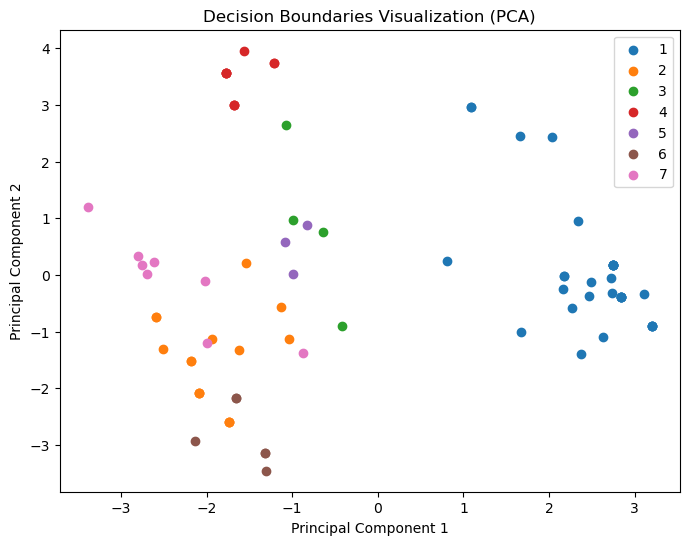

In [48]:
# Generating scatter plot for decision boundaries of the classifier.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Scaling the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)


# Applying PCA to reduce dimensionality to 2 for visualization
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)

# Creating the scatter plot
plt.figure(figsize=(8, 6))
for i in np.unique(Y_train):
    plt.scatter(X_train_pca[Y_train == i, 0], X_train_pca[Y_train == i, 1], label=str(i))
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Decision Boundaries Visualization (PCA)")
plt.legend()
plt.show()


In [72]:
# The scatter plot visualizes the decision boundaries of a K-Nearest Neighbors (KNN) classifier, specifically after applying Principal Component Analysis (PCA) to the training data.

# 1. The original data, representing various animal characteristics, has been reduced to two dimensions using PCA.
# PCA identifies the principal components, which are new, uncorrelated variables that capture the most variance in the original data.
# This reduction allows for visualization in a 2D plot.

# 2. Each point on the scatter plot represents an animal from the training dataset. The points are color-coded according to their animal type.

# 3. While the plot itself doesn't explicitly draw decision boundaries, the clustering of different colored points suggests how the KNN classifier would partition the feature space.
# KNN works by assigning a new data point to the class most common among its k-nearest neighbors in the feature space.
# The proximity of points of different colors implies potential decision boundaries between the classes.

# 4. By observing the plot, we can get a sense of how well-separated the different animal types are in the reduced two-dimensional feature space.
# If the points of different colors are neatly separated, it suggests that the KNN classifier might perform well on this dataset.

In [ ]:
# Interview Questions:

# #1. The following are the diferrent types of hyperparameters in KNN classifier:
# Number of Neighbors (k):
# This determines how many nearest neighbors are considered when making a prediction.
# A larger 'k' can lead to smoother decision boundaries but might mask local patterns, while a smaller 'k' can be more sensitive to noise.
# Distance Metric:
# This defines how the similarity or dissimilarity between data points is measured. We commonly use Euclidean, Manhattan, and Minkowski distances.
# Weights:
# This determines how much influence each neighbor has on the prediction. Options include uniform weights (all neighbors have equal influence) or distance-based weights (closer neighbors have more influence).
# Algorithm:
# The algorithm used to find the nearest neighbors, which can be brute force, k-d tree, or ball tree.

# #2. For the algorithm to work best on a particular dataset we need to choose the most appropriate distance metric accordingly.
# There are a lot of different distance metrics available, but we are only going to talk about a few widely used ones.
# # Euclidean distance function is the most popular one among all of them as it is set default in the SKlearn KNN classifier library in python.

# Euclidean Distance:
# This distance is the most widely used one as it is the default metric that SKlearn library of Python uses for K-Nearest Neighbour.
# # It is a measure of the true straight line distance between two points in Euclidean space.
# Manhattan Distance:
# # The distance between two points is the sum of the absolute differences of their Cartesian coordinates.
# Minkowski Distance:
# It is a metric intended for real-valued vector spaces.